# Descriptive analysis

This notebook summarises the formal 3 × 3 experiment before inferential testing.

It reports software-quality outcomes, efficiency metrics, workflow × specification summaries, automated-refinement behaviour, iteration-level duration and token usage, and initial-to-final quality transitions.

All 90 runs are retained. No composite quality score is created.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

analysis_dir = Path.cwd().parent
outputs_dir = analysis_dir / "outputs"
tables_dir = analysis_dir / "tables"
figures_dir = analysis_dir / "figures"

tables_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

runs = pd.read_csv(
    outputs_dir / "processed_runs.csv",
    parse_dates=["startedAt", "completedAt"],
)

iterations = pd.read_csv(
    outputs_dir / "processed_iterations.csv"
)

workflow_order = [
    "one-shot",
    "quality-focused",
    "automated-refinement",
]

specification_order = [
    "todo",
    "quiz",
    "booking",
]

runs["workflow"] = pd.Categorical(
    runs["workflow"],
    categories=workflow_order,
    ordered=True,
)
runs["specificationId"] = pd.Categorical(
    runs["specificationId"],
    categories=specification_order,
    ordered=True,
)
iterations["workflow"] = pd.Categorical(
    iterations["workflow"],
    categories=workflow_order,
    ordered=True,
)
iterations["specificationId"] = pd.Categorical(
    iterations["specificationId"],
    categories=specification_order,
    ordered=True,
)

print("Run-level rows:", len(runs))
print("Iteration-level rows:", len(iterations))


Run-level rows: 90
Iteration-level rows: 125


## 1. Design validation

In [2]:
design_table = pd.crosstab(
    runs["specificationId"],
    runs["workflow"],
    margins=True,
).reindex(
    index=specification_order + ["All"],
    columns=workflow_order + ["All"],
)

design_table


workflow,one-shot,quality-focused,automated-refinement,All
specificationId,,,,
todo,10,10,10,30
quiz,10,10,10,30
booking,10,10,10,30
All,30,30,30,90


In [3]:
assert len(runs) == 90
assert (
    pd.crosstab(
        runs["specificationId"],
        runs["workflow"],
    )
    .reindex(index=specification_order, columns=workflow_order)
    .eq(10)
    .all()
    .all()
)

print("Balanced 3 × 3 design: PASSED")


Balanced 3 × 3 design: PASSED


## 2. Overall pass outcomes

In [4]:
overall_outcomes = pd.DataFrame(
    {
        "outcome": [
            "Final all checks passed",
            "Final static analysis passed",
            "Final runtime validation passed",
            "Final accessibility validation passed",
            "Final functional validation passed",
        ],
        "passed": [
            int(runs["finalAllPassed"].sum()),
            int(runs["finalStaticPassed"].sum()),
            int(runs["finalRuntimePassed"].sum()),
            int(runs["finalAccessibilityPassed"].sum()),
            int(runs["finalFunctionalPassed"].sum()),
        ],
    }
)

overall_outcomes["total"] = len(runs)
overall_outcomes["failed"] = overall_outcomes["total"] - overall_outcomes["passed"]
overall_outcomes["percentagePassed"] = (
    overall_outcomes["passed"] / overall_outcomes["total"] * 100
)

overall_outcomes = overall_outcomes[
    ["outcome", "passed", "failed", "total", "percentagePassed"]
]

overall_outcomes


,outcome,passed,failed,total,percentagePassed
0,Final all checks passed,51,39,90,56.667
1,Final static analysis passed,64,26,90,71.111
2,Final runtime validation passed,89,1,90,98.889
3,Final accessibility validation passed,63,27,90,70.000
4,Final functional validation passed,86,4,90,95.556


In [5]:
overall_outcomes.to_csv(
    tables_dir / "descriptive_overall_pass_outcomes.csv",
    index=False,
)


## 3. Pass outcomes by workflow

In [6]:
pass_columns = [
    "finalAllPassed",
    "finalStaticPassed",
    "finalRuntimePassed",
    "finalAccessibilityPassed",
    "finalFunctionalPassed",
]

workflow_pass_summary = []

for workflow in workflow_order:
    group = runs.loc[runs["workflow"] == workflow]

    for outcome in pass_columns:
        passed = int(group[outcome].sum())
        total = len(group)

        workflow_pass_summary.append(
            {
                "workflow": workflow,
                "outcome": outcome,
                "passed": passed,
                "failed": total - passed,
                "total": total,
                "percentagePassed": passed / total * 100,
            }
        )

workflow_pass_summary = pd.DataFrame(workflow_pass_summary)
workflow_pass_summary["workflow"] = pd.Categorical(
    workflow_pass_summary["workflow"],
    categories=workflow_order,
    ordered=True,
)
workflow_pass_summary = workflow_pass_summary.sort_values(
    ["workflow", "outcome"]
).reset_index(drop=True)

workflow_pass_summary


,workflow,outcome,passed,failed,total,percentagePassed
0,one-shot,finalAccessibilityPassed,3,27,30,10.000
1,one-shot,finalAllPassed,2,28,30,6.667
2,one-shot,finalFunctionalPassed,29,1,30,96.667
3,one-shot,finalRuntimePassed,30,0,30,100.000
4,one-shot,finalStaticPassed,14,16,30,46.667
5,quality-focused,finalAccessibilityPassed,30,0,30,100.000
6,quality-focused,finalAllPassed,19,11,30,63.333
7,quality-focused,finalFunctionalPassed,27,3,30,90.000
8,quality-focused,finalRuntimePassed,29,1,30,96.667
9,quality-focused,finalStaticPassed,20,10,30,66.667


In [7]:
workflow_pass_summary.to_csv(
    tables_dir / "descriptive_pass_outcomes_by_workflow.csv",
    index=False,
)


## 4. Pass outcomes by specification and workflow

In [8]:
cell_pass_summary = []

for specification in specification_order:
    for workflow in workflow_order:
        group = runs.loc[
            (runs["specificationId"] == specification)
            & (runs["workflow"] == workflow)
        ]

        for outcome in pass_columns:
            passed = int(group[outcome].sum())
            total = len(group)

            cell_pass_summary.append(
                {
                    "specificationId": specification,
                    "workflow": workflow,
                    "outcome": outcome,
                    "passed": passed,
                    "failed": total - passed,
                    "total": total,
                    "percentagePassed": passed / total * 100,
                }
            )

cell_pass_summary = pd.DataFrame(cell_pass_summary)
cell_pass_summary["specificationId"] = pd.Categorical(
    cell_pass_summary["specificationId"],
    categories=specification_order,
    ordered=True,
)
cell_pass_summary["workflow"] = pd.Categorical(
    cell_pass_summary["workflow"],
    categories=workflow_order,
    ordered=True,
)
cell_pass_summary = cell_pass_summary.sort_values(
    ["specificationId", "workflow", "outcome"]
).reset_index(drop=True)

cell_pass_summary.head(20)


,specificationId,workflow,outcome,passed,failed,total,percentagePassed
0,todo,one-shot,finalAccessibilityPassed,2,8,10,20.000
1,todo,one-shot,finalAllPassed,2,8,10,20.000
2,todo,one-shot,finalFunctionalPassed,10,0,10,100.000
3,todo,one-shot,finalRuntimePassed,10,0,10,100.000
4,todo,one-shot,finalStaticPassed,10,0,10,100.000
5,todo,quality-focused,finalAccessibilityPassed,10,0,10,100.000
6,todo,quality-focused,finalAllPassed,8,2,10,80.000
7,todo,quality-focused,finalFunctionalPassed,9,1,10,90.000
8,todo,quality-focused,finalRuntimePassed,10,0,10,100.000
9,todo,quality-focused,finalStaticPassed,9,1,10,90.000


In [9]:
cell_pass_summary.to_csv(
    tables_dir / "descriptive_pass_outcomes_by_cell.csv",
    index=False,
)


## 5. Descriptive summary function

In [10]:
def descriptive_summary(dataframe, group_columns, outcome_columns):
    records = []

    grouped = dataframe.groupby(
        group_columns,
        dropna=False,
        observed=True,
        sort=False,
    )

    for group_values, group in grouped:
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        group_info = dict(zip(group_columns, group_values))

        for outcome in outcome_columns:
            values = pd.to_numeric(
                group[outcome],
                errors="coerce",
            ).dropna()

            records.append(
                {
                    **group_info,
                    "outcome": outcome,
                    "n": int(values.count()),
                    "missing": int(group[outcome].isna().sum()),
                    "mean": values.mean(),
                    "standardDeviation": values.std(ddof=1),
                    "median": values.median(),
                    "q1": values.quantile(0.25),
                    "q3": values.quantile(0.75),
                    "iqr": values.quantile(0.75) - values.quantile(0.25),
                    "minimum": values.min(),
                    "maximum": values.max(),
                }
            )

    return pd.DataFrame(records)


## 6. Continuous and count outcomes

In [11]:
continuous_outcomes = [
    "workflowDurationMs",
    "aiGenerationDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
    "finalStaticTotalIssues",
    "finalStaticErrors",
    "finalStaticWarnings",
    "finalAccessibilityViolations",
    "finalAccessibilityViolatingNodes",
    "finalAccessibilityIncomplete",
    "finalFunctionalPassedTests",
    "finalFunctionalFailedTests",
    "finalFunctionalPassRate",
]


In [12]:
descriptive_by_workflow = descriptive_summary(
    runs,
    ["workflow"],
    continuous_outcomes,
)

descriptive_by_workflow["workflow"] = pd.Categorical(
    descriptive_by_workflow["workflow"],
    categories=workflow_order,
    ordered=True,
)
descriptive_by_workflow = descriptive_by_workflow.sort_values(
    ["workflow", "outcome"]
).reset_index(drop=True)

descriptive_by_workflow.head(20)


,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,one-shot,aiGenerationDurationMs,30,0,"25,235.233","9,890.911","23,721.500","18,501.750","27,820.250","9,318.500","15,604.000","55,982.000"
1,one-shot,finalAccessibilityIncomplete,30,0,1.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000
2,one-shot,finalAccessibilityViolatingNodes,30,0,3.867,2.980,3.500,2.000,5.000,3.000,0.000,13.000
3,one-shot,finalAccessibilityViolations,30,0,0.967,0.414,1.000,1.000,1.000,0.000,0.000,2.000
4,one-shot,finalFunctionalFailedTests,30,0,0.133,0.730,0.000,0.000,0.000,0.000,0.000,4.000
5,one-shot,finalFunctionalPassRate,30,0,0.985,0.081,1.000,1.000,1.000,0.000,0.556,1.000
6,one-shot,finalFunctionalPassedTests,30,0,7.200,1.297,7.000,6.000,9.000,3.000,5.000,9.000
7,one-shot,finalStaticErrors,30,0,0.867,1.042,1.000,0.000,1.000,1.000,0.000,3.000
8,one-shot,finalStaticTotalIssues,30,0,0.967,1.189,1.000,0.000,1.000,1.000,0.000,4.000
9,one-shot,finalStaticWarnings,30,0,0.100,0.305,0.000,0.000,0.000,0.000,0.000,1.000


In [13]:
descriptive_by_workflow.to_csv(
    tables_dir / "descriptive_continuous_by_workflow.csv",
    index=False,
)


In [14]:
descriptive_by_specification = descriptive_summary(
    runs,
    ["specificationId"],
    continuous_outcomes,
)

descriptive_by_specification["specificationId"] = pd.Categorical(
    descriptive_by_specification["specificationId"],
    categories=specification_order,
    ordered=True,
)
descriptive_by_specification = descriptive_by_specification.sort_values(
    ["specificationId", "outcome"]
).reset_index(drop=True)

descriptive_by_specification.head(20)


,specificationId,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,todo,aiGenerationDurationMs,30,0,"30,318.533","14,042.569","24,901.500","19,135.000","37,257.250","18,122.250","15,604.000","60,542.000"
1,todo,finalAccessibilityIncomplete,30,0,0.833,0.648,1.000,0.000,1.000,1.000,0.000,2.000
2,todo,finalAccessibilityViolatingNodes,30,0,0.533,1.137,0.000,0.000,0.750,0.750,0.000,5.000
3,todo,finalAccessibilityViolations,30,0,0.267,0.450,0.000,0.000,0.750,0.750,0.000,1.000
4,todo,finalFunctionalFailedTests,30,0,0.167,0.913,0.000,0.000,0.000,0.000,0.000,5.000
5,todo,finalFunctionalPassRate,30,0,0.972,0.152,1.000,1.000,1.000,0.000,0.167,1.000
6,todo,finalFunctionalPassedTests,30,0,5.833,0.913,6.000,6.000,6.000,0.000,1.000,6.000
7,todo,finalStaticErrors,30,0,0.067,0.365,0.000,0.000,0.000,0.000,0.000,2.000
8,todo,finalStaticTotalIssues,30,0,0.067,0.365,0.000,0.000,0.000,0.000,0.000,2.000
9,todo,finalStaticWarnings,30,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [15]:
descriptive_by_specification.to_csv(
    tables_dir / "descriptive_continuous_by_specification.csv",
    index=False,
)


In [16]:
descriptive_by_cell = descriptive_summary(
    runs,
    ["specificationId", "workflow"],
    continuous_outcomes,
)

descriptive_by_cell["specificationId"] = pd.Categorical(
    descriptive_by_cell["specificationId"],
    categories=specification_order,
    ordered=True,
)
descriptive_by_cell["workflow"] = pd.Categorical(
    descriptive_by_cell["workflow"],
    categories=workflow_order,
    ordered=True,
)
descriptive_by_cell = descriptive_by_cell.sort_values(
    ["specificationId", "workflow", "outcome"]
).reset_index(drop=True)

descriptive_by_cell.head(30)


,specificationId,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,todo,one-shot,aiGenerationDurationMs,10,0,"25,096.700","11,907.862","23,027.500","16,981.250","26,714.750","9,733.500","15,604.000","55,982.000"
1,todo,one-shot,finalAccessibilityIncomplete,10,0,1.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000
2,todo,one-shot,finalAccessibilityViolatingNodes,10,0,1.600,1.506,1.000,1.000,2.000,1.000,0.000,5.000
3,todo,one-shot,finalAccessibilityViolations,10,0,0.800,0.422,1.000,1.000,1.000,0.000,0.000,1.000
4,todo,one-shot,finalFunctionalFailedTests,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,todo,one-shot,finalFunctionalPassRate,10,0,1.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000
6,todo,one-shot,finalFunctionalPassedTests,10,0,6.000,0.000,6.000,6.000,6.000,0.000,6.000,6.000
7,todo,one-shot,finalStaticErrors,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,todo,one-shot,finalStaticTotalIssues,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,todo,one-shot,finalStaticWarnings,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [17]:
descriptive_by_cell.to_csv(
    tables_dir / "descriptive_continuous_by_cell.csv",
    index=False,
)


## 7. Dissertation-ready primary outcome table

In [18]:
primary_pass_table = (
    runs.groupby(
        ["specificationId", "workflow"],
        observed=True,
        sort=False,
    )["finalAllPassed"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "passed", "count": "total"})
    .reset_index()
)

primary_pass_table["failed"] = (
    primary_pass_table["total"] - primary_pass_table["passed"]
)
primary_pass_table["percentagePassed"] = (
    primary_pass_table["passed"] / primary_pass_table["total"] * 100
)

primary_pass_table["specificationId"] = pd.Categorical(
    primary_pass_table["specificationId"],
    categories=specification_order,
    ordered=True,
)
primary_pass_table["workflow"] = pd.Categorical(
    primary_pass_table["workflow"],
    categories=workflow_order,
    ordered=True,
)

primary_pass_table = primary_pass_table[
    [
        "specificationId",
        "workflow",
        "passed",
        "failed",
        "total",
        "percentagePassed",
    ]
].sort_values(
    ["specificationId", "workflow"]
).reset_index(drop=True)

primary_pass_table


,specificationId,workflow,passed,failed,total,percentagePassed
0,todo,one-shot,2,8,10,20.000
1,todo,quality-focused,8,2,10,80.000
2,todo,automated-refinement,10,0,10,100.000
3,quiz,one-shot,0,10,10,0.000
4,quiz,quality-focused,9,1,10,90.000
5,quiz,automated-refinement,10,0,10,100.000
6,booking,one-shot,0,10,10,0.000
7,booking,quality-focused,2,8,10,20.000
8,booking,automated-refinement,10,0,10,100.000


In [19]:
primary_pass_table.to_csv(
    tables_dir / "table_primary_quality_outcome.csv",
    index=False,
)


## 8. Efficiency summary

In [20]:
efficiency_columns = [
    "aiGenerationDurationMs",
    "workflowDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
]

efficiency_table = descriptive_summary(
    runs,
    ["workflow"],
    efficiency_columns,
)

efficiency_table["workflow"] = pd.Categorical(
    efficiency_table["workflow"],
    categories=workflow_order,
    ordered=True,
)
efficiency_table = efficiency_table.sort_values(
    ["workflow", "outcome"]
).reset_index(drop=True)

efficiency_table


,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,one-shot,aiGenerationDurationMs,30,0,"25,235.233","9,890.911","23,721.500","18,501.750","27,820.250","9,318.500",15604,55982
1,one-shot,pipelineOverheadMs,30,0,"3,597.000","2,233.688","3,121.500","2,636.250","3,628.500",992.250,2116,14937
2,one-shot,totalOutputTokens,30,0,"2,906.867",402.898,"2,757.000","2,641.000","3,203.000",562.000,2059,3969
3,one-shot,totalPromptTokens,30,0,757.667,27.821,743.000,734.000,796.000,62.000,734,796
4,one-shot,totalTokens,30,0,"3,664.533",426.617,"3,495.500","3,381.000","3,999.000",618.000,2802,4765
5,one-shot,workflowDurationMs,30,0,"28,832.233","10,332.943","27,321.000","21,360.000","31,480.750","10,120.750",18208,60445
6,quality-focused,aiGenerationDurationMs,30,0,"24,912.600","15,308.457","19,957.000","18,959.250","24,589.000","5,629.750",15660,95302
7,quality-focused,pipelineOverheadMs,30,0,"2,767.833","2,712.525","2,172.500","2,065.750","2,404.750",339.000,1939,16937
8,quality-focused,totalOutputTokens,30,0,"2,840.133",304.961,"2,792.500","2,668.000","3,038.750",370.750,2065,3468
9,quality-focused,totalPromptTokens,30,0,920.667,27.821,906.000,897.000,959.000,62.000,897,959


In [21]:
efficiency_table.to_csv(
    tables_dir / "table_efficiency_by_workflow.csv",
    index=False,
)


## 9. Automated-refinement run-level summary

In [22]:
automated = runs.loc[
    runs["workflow"] == "automated-refinement"
].copy()

refinement_iteration_counts = (
    automated["refinementIterations"]
    .value_counts()
    .sort_index()
    .rename_axis("refinementIterations")
    .reset_index(name="runs")
)

refinement_iteration_counts["percentage"] = (
    refinement_iteration_counts["runs"] / len(automated) * 100
)

refinement_iteration_counts


,refinementIterations,runs,percentage
0,0,1,3.333
1,1,23,76.667
2,2,6,20.000


In [23]:
refinement_iteration_counts.to_csv(
    tables_dir / "descriptive_refinement_iterations.csv",
    index=False,
)


In [24]:
automated_change_columns = [
    "staticIssueChange",
    "accessibilityViolationChange",
    "functionalFailedTestChange",
]

automated_change_summary = descriptive_summary(
    automated.assign(group="automated-refinement"),
    ["group"],
    automated_change_columns,
)

automated_change_summary


,group,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,automated-refinement,staticIssueChange,30,0,-1.233,1.223,-1.000,-2.000,0.000,2.000,-4,0
1,automated-refinement,accessibilityViolationChange,30,0,-0.967,0.556,-1.000,-1.000,-1.000,0.000,-2,0
2,automated-refinement,functionalFailedTestChange,30,0,-0.033,0.183,0.000,0.000,0.000,0.000,-1,0


In [25]:
automated_change_summary.to_csv(
    tables_dir / "descriptive_automated_changes.csv",
    index=False,
)


## 10. Automated-refinement pass transitions

In [26]:
automated_all_pass_transitions = pd.crosstab(
    automated["initialAllPassed"],
    automated["finalAllPassed"],
    rownames=["initialAllPassed"],
    colnames=["finalAllPassed"],
)

automated_all_pass_transitions


finalAllPassed,True
initialAllPassed,
False,28
True,2


In [27]:
automated_all_pass_transitions.to_csv(
    tables_dir / "automated_initial_final_pass_transitions.csv"
)


In [28]:
transition_outcomes = [
    ("Static analysis", "initialStaticPassed", "finalStaticPassed"),
    ("Runtime validation", "initialRuntimePassed", "finalRuntimePassed"),
    (
        "Accessibility validation",
        "initialAccessibilityPassed",
        "finalAccessibilityPassed",
    ),
    (
        "Functional validation",
        "initialFunctionalPassed",
        "finalFunctionalPassed",
    ),
    ("All checks", "initialAllPassed", "finalAllPassed"),
]

transition_records = []

for label, initial_column, final_column in transition_outcomes:
    transition_records.append(
        {
            "outcome": label,
            "failedToFailed": int(
                ((~automated[initial_column]) & (~automated[final_column])).sum()
            ),
            "failedToPassed": int(
                ((~automated[initial_column]) & automated[final_column]).sum()
            ),
            "passedToFailed": int(
                (automated[initial_column] & (~automated[final_column])).sum()
            ),
            "passedToPassed": int(
                (automated[initial_column] & automated[final_column]).sum()
            ),
        }
    )

automated_domain_transitions = pd.DataFrame(transition_records)

automated_domain_transitions


,outcome,failedToFailed,failedToPassed,passedToFailed,passedToPassed
0,Static analysis,0,19,0,11
1,Runtime validation,0,0,0,30
2,Accessibility validation,0,25,0,5
3,Functional validation,0,1,0,29
4,All checks,0,28,0,2


In [29]:
automated_domain_transitions.to_csv(
    tables_dir / "automated_domain_pass_transitions.csv",
    index=False,
)


## 11. Automated-refinement initial and final quality counts

In [30]:
automated_initial_final_summary = pd.DataFrame(
    {
        "metric": [
            "Static issues",
            "Static errors",
            "Static warnings",
            "Accessibility violations",
            "Accessibility violating nodes",
            "Functional failed tests",
        ],
        "initialMean": [
            automated["initialStaticTotalIssues"].mean(),
            automated["initialStaticErrors"].mean(),
            automated["initialStaticWarnings"].mean(),
            automated["initialAccessibilityViolations"].mean(),
            automated["initialAccessibilityViolatingNodes"].mean(),
            automated["initialFunctionalFailedTests"].mean(),
        ],
        "initialMedian": [
            automated["initialStaticTotalIssues"].median(),
            automated["initialStaticErrors"].median(),
            automated["initialStaticWarnings"].median(),
            automated["initialAccessibilityViolations"].median(),
            automated["initialAccessibilityViolatingNodes"].median(),
            automated["initialFunctionalFailedTests"].median(),
        ],
        "finalMean": [
            automated["finalStaticTotalIssues"].mean(),
            automated["finalStaticErrors"].mean(),
            automated["finalStaticWarnings"].mean(),
            automated["finalAccessibilityViolations"].mean(),
            automated["finalAccessibilityViolatingNodes"].mean(),
            automated["finalFunctionalFailedTests"].mean(),
        ],
        "finalMedian": [
            automated["finalStaticTotalIssues"].median(),
            automated["finalStaticErrors"].median(),
            automated["finalStaticWarnings"].median(),
            automated["finalAccessibilityViolations"].median(),
            automated["finalAccessibilityViolatingNodes"].median(),
            automated["finalFunctionalFailedTests"].median(),
        ],
    }
)

automated_initial_final_summary


,metric,initialMean,initialMedian,finalMean,finalMedian
0,Static issues,1.233,1.000,0.000,0.000
1,Static errors,1.000,1.000,0.000,0.000
2,Static warnings,0.233,0.000,0.000,0.000
3,Accessibility violations,0.967,1.000,0.000,0.000
4,Accessibility violating nodes,3.467,3.000,0.000,0.000
5,Functional failed tests,0.033,0.000,0.000,0.000


In [31]:
automated_initial_final_summary.to_csv(
    tables_dir / "automated_initial_final_quality_summary.csv",
    index=False,
)


## 12. Automated-refinement iteration-level efficiency

In [32]:
automated_iterations = iterations.loc[
    iterations["workflow"] == "automated-refinement"
].copy()

automated_iterations["generationDurationSeconds"] = (
    automated_iterations["generationDurationMs"] / 1000
)

automated_iterations = automated_iterations.sort_values(
    ["experimentRunId", "iteration"]
).reset_index(drop=True)

automated_iterations["cumulativeGenerationDurationMs"] = (
    automated_iterations
    .groupby("experimentRunId")["generationDurationMs"]
    .cumsum()
)

automated_iterations["cumulativeTotalTokens"] = (
    automated_iterations
    .groupby("experimentRunId")["totalTokens"]
    .cumsum()
)

automated_iterations.head()


,experimentId,experimentRunId,sequence,specificationId,workflow,repetition,runId,iteration,iterationType,generationDurationMs,promptTokens,outputTokens,totalTokens,generationDurationSeconds,cumulativeGenerationDurationMs,cumulativeTotalTokens
0,experiment-2026-08-03T14-15-25-809Z-f77080fe,booking__automated-refinement__1,26,booking,automated-refinement,1,2026-08-03T14-31-45-391Z-37dd36f3,0,initial-generation,27228,796,3577,4373,27.228,27228,4373
1,experiment-2026-08-03T14-15-25-809Z-f77080fe,booking__automated-refinement__1,26,booking,automated-refinement,1,2026-08-03T14-31-45-391Z-37dd36f3,1,refinement,20603,5600,3665,9265,20.603,47831,13638
2,experiment-2026-08-03T14-15-25-809Z-f77080fe,booking__automated-refinement__1,26,booking,automated-refinement,1,2026-08-03T14-31-45-391Z-37dd36f3,2,refinement,18412,5185,3673,8858,18.412,66243,22496
3,experiment-2026-08-03T14-15-25-809Z-f77080fe,booking__automated-refinement__10,16,booking,automated-refinement,10,2026-08-03T14-24-32-447Z-e1b0b2c9,0,initial-generation,46449,796,3162,3958,46.449,46449,3958
4,experiment-2026-08-03T14-15-25-809Z-f77080fe,booking__automated-refinement__10,16,booking,automated-refinement,10,2026-08-03T14-24-32-447Z-e1b0b2c9,1,refinement,19842,5222,3263,8485,19.842,66291,12443


In [33]:
iteration_availability = (
    automated_iterations.groupby(
        "iteration",
        observed=True,
        sort=True,
    )
    .agg(
        runs=("experimentRunId", "nunique"),
        meanGenerationDurationMs=("generationDurationMs", "mean"),
        medianGenerationDurationMs=("generationDurationMs", "median"),
        standardDeviationGenerationDurationMs=("generationDurationMs", "std"),
        meanPromptTokens=("promptTokens", "mean"),
        medianPromptTokens=("promptTokens", "median"),
        meanOutputTokens=("outputTokens", "mean"),
        medianOutputTokens=("outputTokens", "median"),
        meanTotalTokens=("totalTokens", "mean"),
        medianTotalTokens=("totalTokens", "median"),
    )
    .reset_index()
)

iteration_availability


,iteration,runs,meanGenerationDurationMs,medianGenerationDurationMs,standardDeviationGenerationDurationMs,meanPromptTokens,medianPromptTokens,meanOutputTokens,medianOutputTokens,meanTotalTokens,medianTotalTokens
0,0,30,"23,809.267","21,925.000","7,673.147",757.667,743.000,"2,928.400","2,787.000","3,686.067","3,524.500"
1,1,29,"21,263.862","19,375.000","5,900.014","4,652.724","4,410.000","2,947.724","2,771.000","7,600.448","7,163.000"
2,2,6,"16,857.500","14,435.500","4,780.184","4,456.667","4,185.500","2,898.333","2,682.500","7,355.000","6,850.000"


In [34]:
iteration_availability.to_csv(
    tables_dir / "descriptive_automated_iteration_metrics.csv",
    index=False,
)


In [35]:
automated_run_resources = (
    automated_iterations
    .groupby(
        "experimentRunId",
        observed=True,
        sort=False,
    )
    .agg(
        specificationId=("specificationId", "first"),
        refinementIterations=("iteration", "max"),
        totalAIGenerationDurationMs=("generationDurationMs", "sum"),
        totalPromptTokens=("promptTokens", "sum"),
        totalOutputTokens=("outputTokens", "sum"),
        totalTokens=("totalTokens", "sum"),
    )
    .reset_index()
)

automated_run_resources.head()


,experimentRunId,specificationId,refinementIterations,totalAIGenerationDurationMs,totalPromptTokens,totalOutputTokens,totalTokens
0,booking__automated-refinement__1,booking,2,66243,11581,10915,22496
1,booking__automated-refinement__10,booking,2,80485,11012,9606,20618
2,booking__automated-refinement__2,booking,1,43918,5967,6106,12073
3,booking__automated-refinement__3,booking,1,72159,6327,6951,13278
4,booking__automated-refinement__4,booking,1,47771,6270,7286,13556


In [36]:
resource_summary_by_refinement_count = descriptive_summary(
    automated_run_resources,
    ["refinementIterations"],
    [
        "totalAIGenerationDurationMs",
        "totalPromptTokens",
        "totalOutputTokens",
        "totalTokens",
    ],
)

resource_summary_by_refinement_count


,refinementIterations,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,2,totalAIGenerationDurationMs,6,0,"63,590.333","12,267.646","63,392.500","53,574.500","71,721.750","18,147.250",49472,80485
1,2,totalPromptTokens,6,0,"9,954.167","1,056.790","9,330.000","9,265.750","10,605.500","1,339.750",9209,11581
2,2,totalOutputTokens,6,0,"8,734.000","1,263.675","8,104.000","7,916.000","9,272.250","1,356.250",7766,10915
3,2,totalTokens,6,0,"18,688.167","2,310.300","17,434.000","17,141.250","19,877.750","2,736.500",17029,22496
4,1,totalAIGenerationDurationMs,23,0,"44,460.261","9,711.499","44,246.000","36,656.500","48,388.000","11,731.500",31997,72159
5,1,totalPromptTokens,23,0,"5,388.696",579.715,"5,128.000","4,966.500","6,018.500","1,052.000",4546,6327
6,1,totalOutputTokens,23,0,"5,891.304",762.113,"5,564.000","5,377.000","6,476.500","1,099.500",4799,7286
7,1,totalTokens,23,0,"11,280.000","1,319.493","10,624.000","10,374.500","12,442.000","2,067.500",9345,13556
8,0,totalAIGenerationDurationMs,1,0,"27,947.000",NaN,"27,947.000","27,947.000","27,947.000",0.000,27947,27947
9,0,totalPromptTokens,1,0,734.000,NaN,734.000,734.000,734.000,0.000,734,734


In [37]:
resource_summary_by_refinement_count.to_csv(
    tables_dir / "descriptive_automated_resources_by_iteration_count.csv",
    index=False,
)


### Interpretation boundary

The iteration-level processed dataset contains duration and token metrics for every iteration. It does not contain full static, runtime, accessibility and functional quality reports for every intermediate iteration.

Therefore:

- iteration-by-iteration efficiency is summarised directly;
- quality is compared between iteration 0 and the final iteration;
- intermediate quality states are not inferred.


## 13. Figures

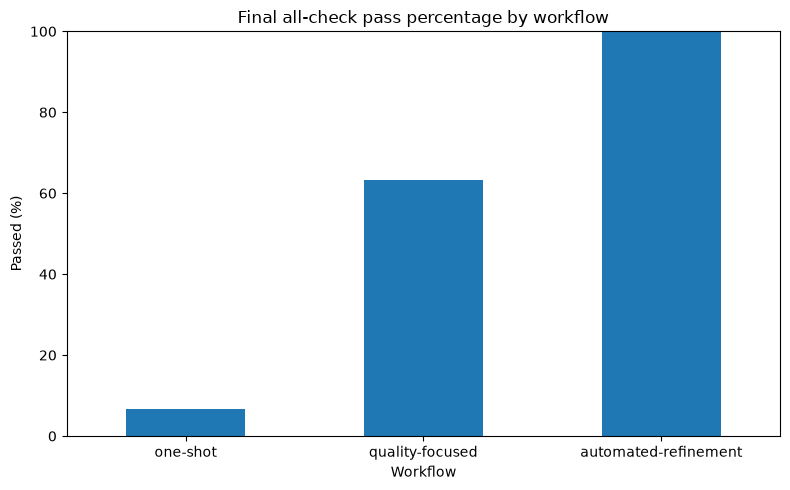

In [38]:
workflow_primary = (
    runs.groupby(
        "workflow",
        observed=True,
        sort=False,
    )["finalAllPassed"]
    .mean()
    .mul(100)
    .reindex(workflow_order)
)

figure, axis = plt.subplots(figsize=(8, 5))
workflow_primary.plot(kind="bar", ax=axis)

axis.set_title("Final all-check pass percentage by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("Passed (%)")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "final_all_pass_percentage_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


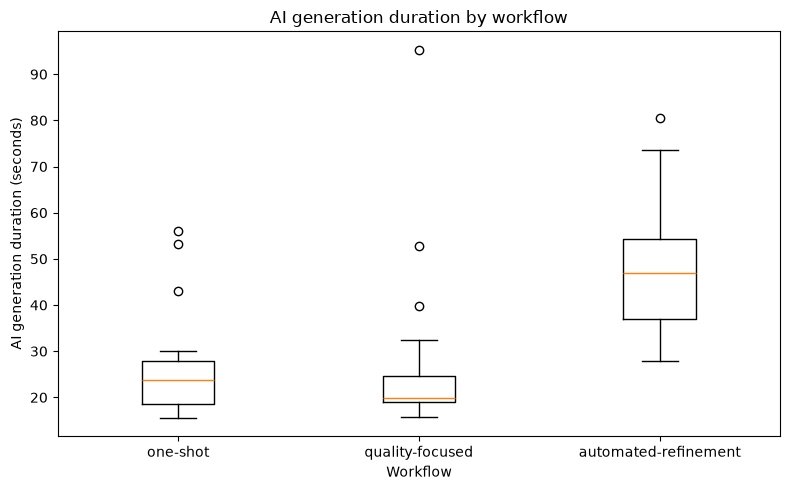

In [39]:
duration_data = [
    runs.loc[
        runs["workflow"] == workflow,
        "aiGenerationDurationSeconds",
    ].dropna()
    for workflow in workflow_order
]

figure, axis = plt.subplots(figsize=(8, 5))
axis.boxplot(duration_data, tick_labels=workflow_order)

axis.set_title("AI generation duration by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("AI generation duration (seconds)")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "ai_generation_duration_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


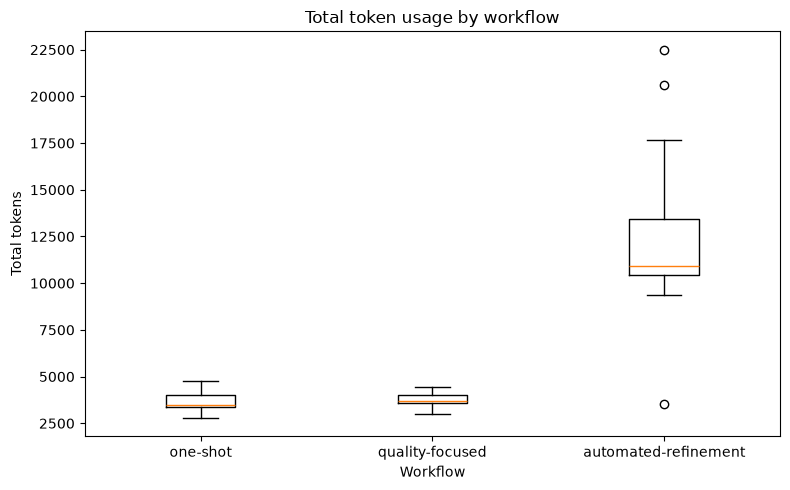

In [40]:
token_data = [
    runs.loc[
        runs["workflow"] == workflow,
        "totalTokens",
    ].dropna()
    for workflow in workflow_order
]

figure, axis = plt.subplots(figsize=(8, 5))
axis.boxplot(token_data, tick_labels=workflow_order)

axis.set_title("Total token usage by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("Total tokens")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "total_tokens_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


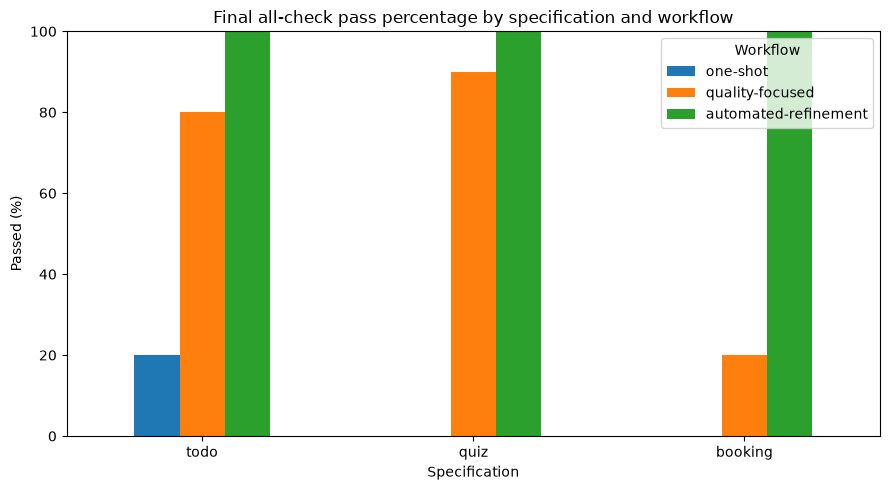

In [41]:
pass_by_cell = (
    runs.groupby(
        ["specificationId", "workflow"],
        observed=True,
        sort=False,
    )["finalAllPassed"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(
        index=specification_order,
        columns=workflow_order,
    )
)

figure, axis = plt.subplots(figsize=(9, 5))
pass_by_cell.plot(kind="bar", ax=axis)

axis.set_title(
    "Final all-check pass percentage by specification and workflow"
)
axis.set_xlabel("Specification")
axis.set_ylabel("Passed (%)")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Workflow")

figure.tight_layout()
figure.savefig(
    figures_dir / "final_pass_percentage_by_specification_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


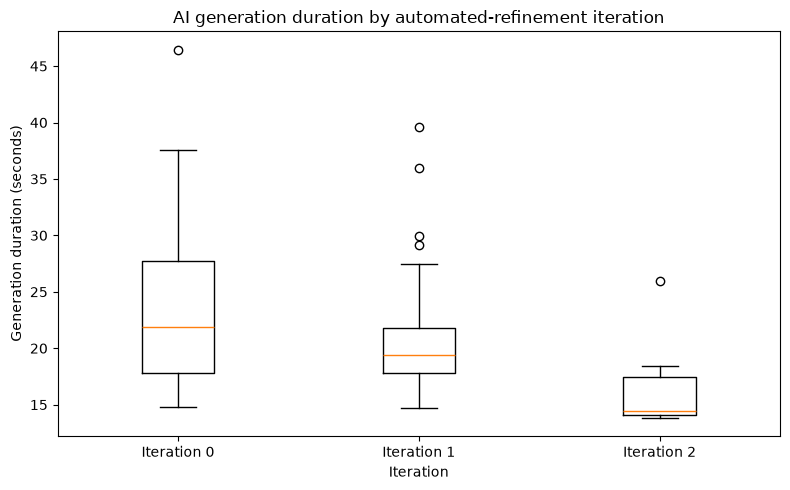

In [42]:
iteration_order = sorted(
    automated_iterations["iteration"].unique()
)

duration_by_iteration = [
    automated_iterations.loc[
        automated_iterations["iteration"] == iteration,
        "generationDurationSeconds",
    ].dropna()
    for iteration in iteration_order
]

figure, axis = plt.subplots(figsize=(8, 5))
axis.boxplot(
    duration_by_iteration,
    tick_labels=[f"Iteration {value}" for value in iteration_order],
)

axis.set_title(
    "AI generation duration by automated-refinement iteration"
)
axis.set_xlabel("Iteration")
axis.set_ylabel("Generation duration (seconds)")

figure.tight_layout()
figure.savefig(
    figures_dir / "automated_generation_duration_by_iteration.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


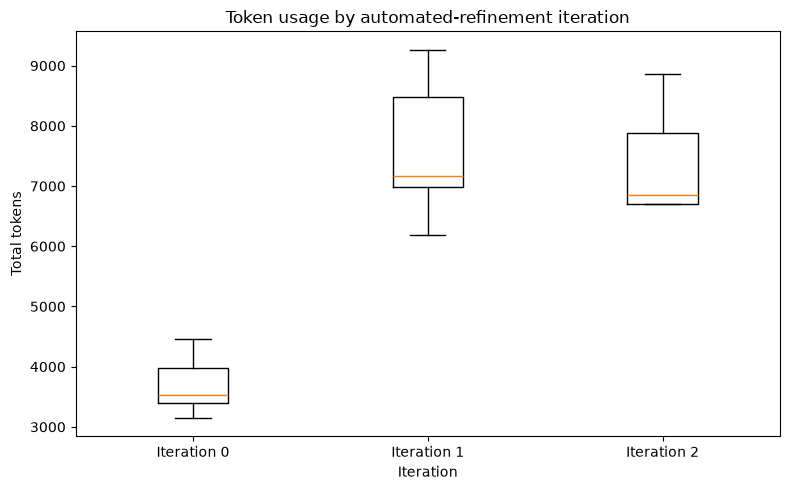

In [43]:
tokens_by_iteration = [
    automated_iterations.loc[
        automated_iterations["iteration"] == iteration,
        "totalTokens",
    ].dropna()
    for iteration in iteration_order
]

figure, axis = plt.subplots(figsize=(8, 5))
axis.boxplot(
    tokens_by_iteration,
    tick_labels=[f"Iteration {value}" for value in iteration_order],
)

axis.set_title("Token usage by automated-refinement iteration")
axis.set_xlabel("Iteration")
axis.set_ylabel("Total tokens")

figure.tight_layout()
figure.savefig(
    figures_dir / "automated_tokens_by_iteration.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


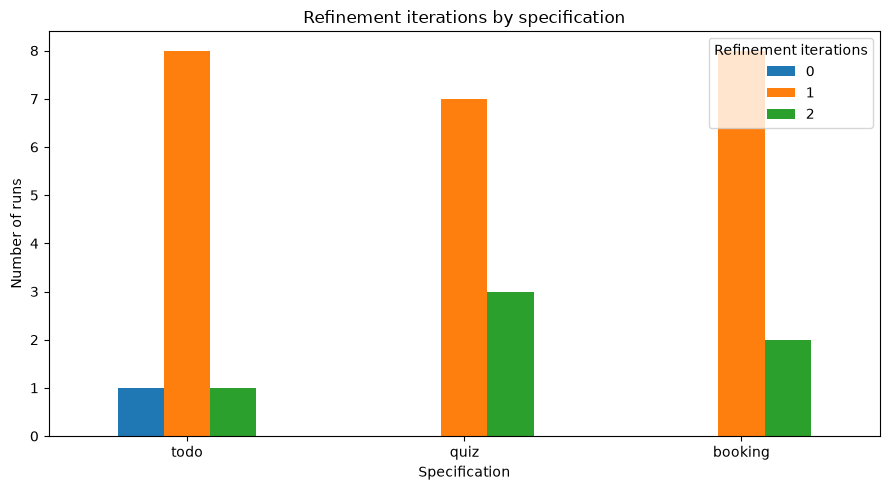

In [44]:
refinement_by_specification = pd.crosstab(
    automated["specificationId"],
    automated["refinementIterations"],
).reindex(specification_order)

figure, axis = plt.subplots(figsize=(9, 5))
refinement_by_specification.plot(kind="bar", ax=axis)

axis.set_title("Refinement iterations by specification")
axis.set_xlabel("Specification")
axis.set_ylabel("Number of runs")
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Refinement iterations")

figure.tight_layout()
figure.savefig(
    figures_dir / "automated_refinement_counts_by_specification.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 14. Output validation

In [45]:
expected_tables = [
    "descriptive_overall_pass_outcomes.csv",
    "descriptive_pass_outcomes_by_workflow.csv",
    "descriptive_pass_outcomes_by_cell.csv",
    "descriptive_continuous_by_workflow.csv",
    "descriptive_continuous_by_specification.csv",
    "descriptive_continuous_by_cell.csv",
    "table_primary_quality_outcome.csv",
    "table_efficiency_by_workflow.csv",
    "descriptive_refinement_iterations.csv",
    "descriptive_automated_changes.csv",
    "automated_initial_final_pass_transitions.csv",
    "automated_domain_pass_transitions.csv",
    "automated_initial_final_quality_summary.csv",
    "descriptive_automated_iteration_metrics.csv",
    "descriptive_automated_resources_by_iteration_count.csv",
]

expected_figures = [
    "final_all_pass_percentage_by_workflow.png",
    "ai_generation_duration_by_workflow.png",
    "total_tokens_by_workflow.png",
    "final_pass_percentage_by_specification_workflow.png",
    "automated_generation_duration_by_iteration.png",
    "automated_tokens_by_iteration.png",
    "automated_refinement_counts_by_specification.png",
]

for filename in expected_tables:
    assert (tables_dir / filename).exists(), filename

for filename in expected_figures:
    assert (figures_dir / filename).exists(), filename

assert len(runs) == 90
assert len(automated) == 30
assert len(automated_iterations) == 65

print("Descriptive-analysis outputs: PASSED")


Descriptive-analysis outputs: PASSED
